# **Urban Water Demand Predcition with Climate Signals**

**Author** - Wimansa Deshani Rajakaruna

**Duration** - 90 mins

**Level** - Intermediate

**Pre-requisite skills** - Python, Data Visualisation, Data Analysis, Time-series Analysis, ML Modelling, Deep Learning

**Project Description** - This project focuses on predicting water consumption using deep learning models that incorporate climate variables such temperature, rainfall, wind speed.

**Gap Addressed** - Water demand is influenced by both weather conditions and human activity patterns, making accurate forecasting complex and challenging.

**Objectives** -

1.   Forecast water demand
2.   Integrate weather and climate data
3.   Support water resource planning


## **Introduction**

Due to the substantial growth of the population and climate variability, accurate urban water demand forcasting is essential for water resource management. Traditional statistical models such as SARIMA are effective at capturing linear seasonal patterns and trends but fails to incorporate climate signals that significantly influence daily water consumption. Hybrid deep learning approaches, combining SARIMA with Long-Short Term Memory (LSTM) models can improve forecast accuracy by monitoring the nonlinearity that statistical models can not capture.

This project develops a SARIMA-LSTM hybrid model integrating climate variables with historical water consumption data to improve urban water demand forecasting accuracy. Two real-world datasets were used in this study. Daily urban water consumption data was source from the Municipal Artificial Intelligence Applications Lab GitHub Repository (Link - https://github.com/aildnont/water-forecast), representing citywide water demand for the City of London Ontario, Canada from July 2019 to September 2020. Historical climate data was obtained from the Open-Meteo Historical Weather API, which provides ERA5 reanalysis data produced by the European Centre for Medium-Range Weather Forecasts. Eight different climate variables were extracted for the same geographic location including Mean Temperature, Precipitation, Rainfall, Wind_Speed, ET0, Solar_Radiation, covering from January 2015 to December 2020. Both data sets were merged using an inner join on the Date column, producing a clean dataset.

This model is aiming to leverage the strengths of both approaches, SARIMA model captures the predictable seasonal demand patterns, while LSTM model captures the residual climate-driven variation. At the end, feature importance analysis is conducted to identify which climate variable influence most to the hybrid model's predictive performance.

## **Exploratory Data Analysis**

Import all the libraries.

In [ ]:
# import all the libraries
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load Water Consumption Data**

In [ ]:
# load the datasets
water_consumption_data = pd.read_csv("water_consumption_data.csv")
# rename the columns
# Date represents a timestamp
# Demand is the total water consumption on that date
water_consumption_data = water_consumption_data.rename(columns={"Consumption":"Demand"})
water_consumption_data.head()

,Date,Demand
0,1/7/2009,108637.2762
1,2/7/2009,108638.8474
2,3/7/2009,108633.8275
3,4/7/2009,109082.4222
4,5/7/2009,109071.7580


**Load Climate Data**

In [ ]:
# climate data
climate_data = pd.read_csv("london_climate.csv")
climate_data.head()

,Date,Temp_Mean,Temp_Max,Temp_Min,Precipitation,Rainfall,Wind_Speed,ET0,Solar_Radiation
0,2015-01-01 04:00:00,-5.543417,-2.883,-8.433001,0.000000,0.000000,31.056128,1.180087,4.59
1,2015-01-02 04:00:00,-2.745500,-0.633,-3.983000,0.000000,0.000000,23.000591,0.876756,5.99
2,2015-01-03 04:00:00,-1.049667,4.067,-4.033000,18.099997,13.099998,20.188908,0.294635,0.81
3,2015-01-04 04:00:00,1.317000,3.917,-5.633000,8.300000,6.000000,28.146843,0.297200,2.04
4,2015-01-05 04:00:00,-12.037168,-6.483,-14.433001,0.000000,0.000000,29.598919,0.682800,7.04


**Merge Two Datasets**

In [ ]:
# re-create the date format
water_consumption_data["Date"] = pd.to_datetime(water_consumption_data["Date"], dayfirst=True)
# strip the time zone from climate dataset
climate_data["Date"] = pd.to_datetime(climate_data["Date"]).dt.normalize()
climate_data = climate_data.drop(columns=["Temp_Max", "Temp_Min"])

In [ ]:
# check null values - no null values
water_consumption_data.isnull().sum().sum()

0

In [ ]:
# no null values
climate_data.isnull().sum().sum()

0

In [ ]:
# merge two datasets on dates from 2015 Jan-2020 Sep
df = pd.merge(water_consumption_data,climate_data, on="Date",how="inner")
df.head()

,Date,Demand,Temp_Mean,Precipitation,Rainfall,Wind_Speed,ET0,Solar_Radiation
0,2015-01-01,98343.49626,-5.543417,0.000000,0.000000,31.056128,1.180087,4.59
1,2015-01-02,98343.69374,-2.745500,0.000000,0.000000,23.000591,0.876756,5.99
2,2015-01-03,98684.73359,-1.049667,18.099997,13.099998,20.188908,0.294635,0.81
3,2015-01-04,98684.84818,1.317000,8.300000,6.000000,28.146843,0.297200,2.04
4,2015-01-05,98685.22039,-12.037168,0.000000,0.000000,29.598919,0.682800,7.04


In [ ]:
df.dtypes # check data types

Date               datetime64[us]
Demand                    float64
Temp_Mean                 float64
Precipitation             float64
Rainfall                  float64
Wind_Speed                float64
ET0                       float64
Solar_Radiation           float64
dtype: object

In [ ]:
# summary statistics for all numeric columns
summary_stat = df.drop(columns=["Date"]).describe() # drop the date column
print(summary_stat)

              Demand    Temp_Mean  Precipitation     Rainfall   Wind_Speed  \
count    2004.000000  2004.000000    2004.000000  2004.000000  2004.000000   
mean   107978.285595     9.077903       2.781587     2.383333    19.486181   
std      9022.978383    10.803515       5.452121     5.330397     6.482443   
min     94995.010460   -22.166334       0.000000     0.000000     6.162207   
25%    100819.513525     0.324479       0.000000     0.000000    14.618837   
50%    104973.164650     9.141666       0.300000     0.000000    18.766664   
75%    114697.662250    19.127167       3.100000     1.900000    23.863409   
max    135780.426500    27.900337      51.699997    51.699997    50.975285   

               ET0  Solar_Radiation  
count  2004.000000      2004.000000  
mean      2.444930        14.179476  
std       1.725590         8.260710  
min       0.159680         0.730000  
25%       0.842876         6.897500  
50%       2.057534        13.405000  
75%       3.813426        21.04

The descriptive statistics reveal that the average daily water demand for the city is approximately 107,978 m3 across the study period from January 2015 to September 2021. The average daily temperature is around 9.1C and the rainfall is approximately 2.4 mm, while precipitation averages around 2.8 mm. The mean wind speed is around 19.5 kmh. These statistics provides an initial overview of the dataset.

**Outlier Detection**

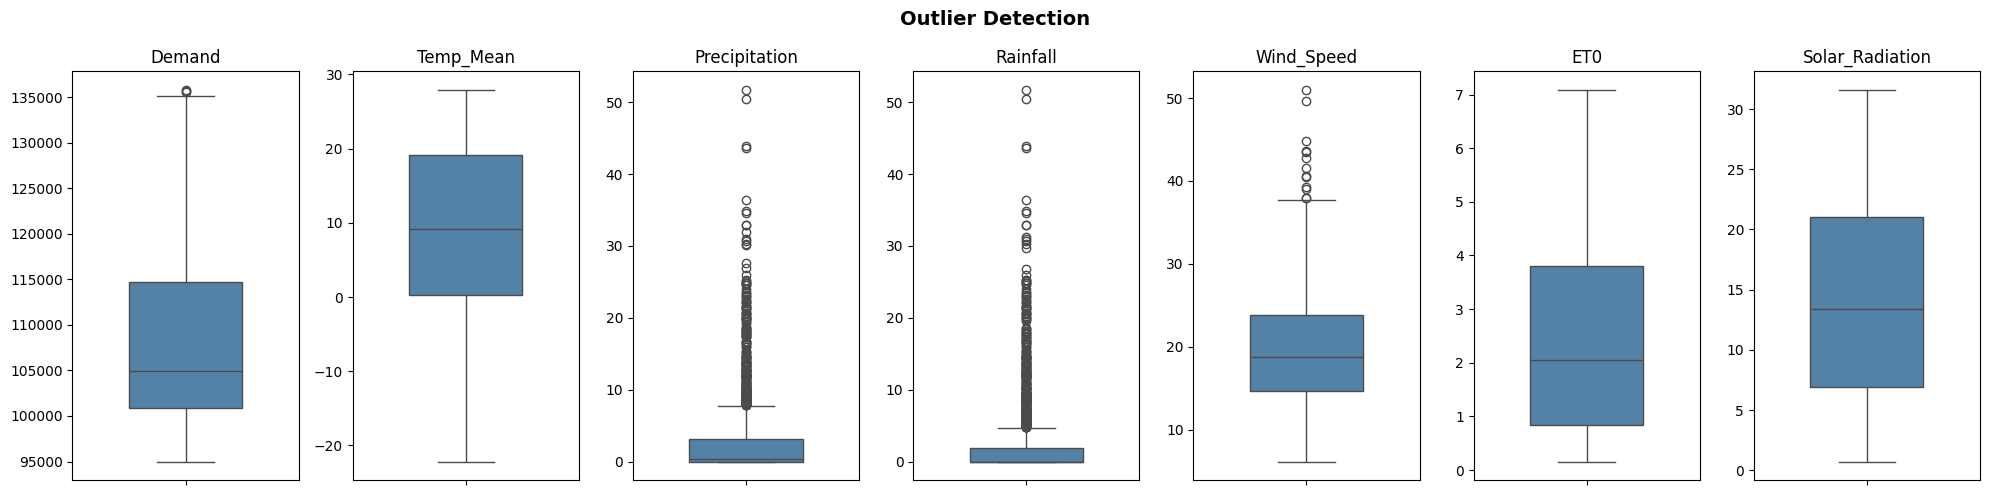

In [ ]:
# outlier detection (exclude date column)
df_1 = pd.DataFrame(df.drop(columns=["Date"]))
fig, axes = plt.subplots(1,7, figsize=(20,5))
axes = axes.flatten()

for i, col in enumerate(df_1.columns):
  sns.boxplot(y=df_1[col], ax=axes[i], color='steelblue', width=0.5)
  axes[i].set_title(f'{col}', fontsize=12)
  axes[i].set_ylabel('')
# give title
plt.suptitle("Outlier Detection", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Outlier detecton is visulaised through box plots. Outliers were identified in precipitation, rainfall, wind speed variables. These outliers are remained as it is, becasue removing the anomalies would result in information loss or give negative impact to the model.

**Time-Series Analysis**

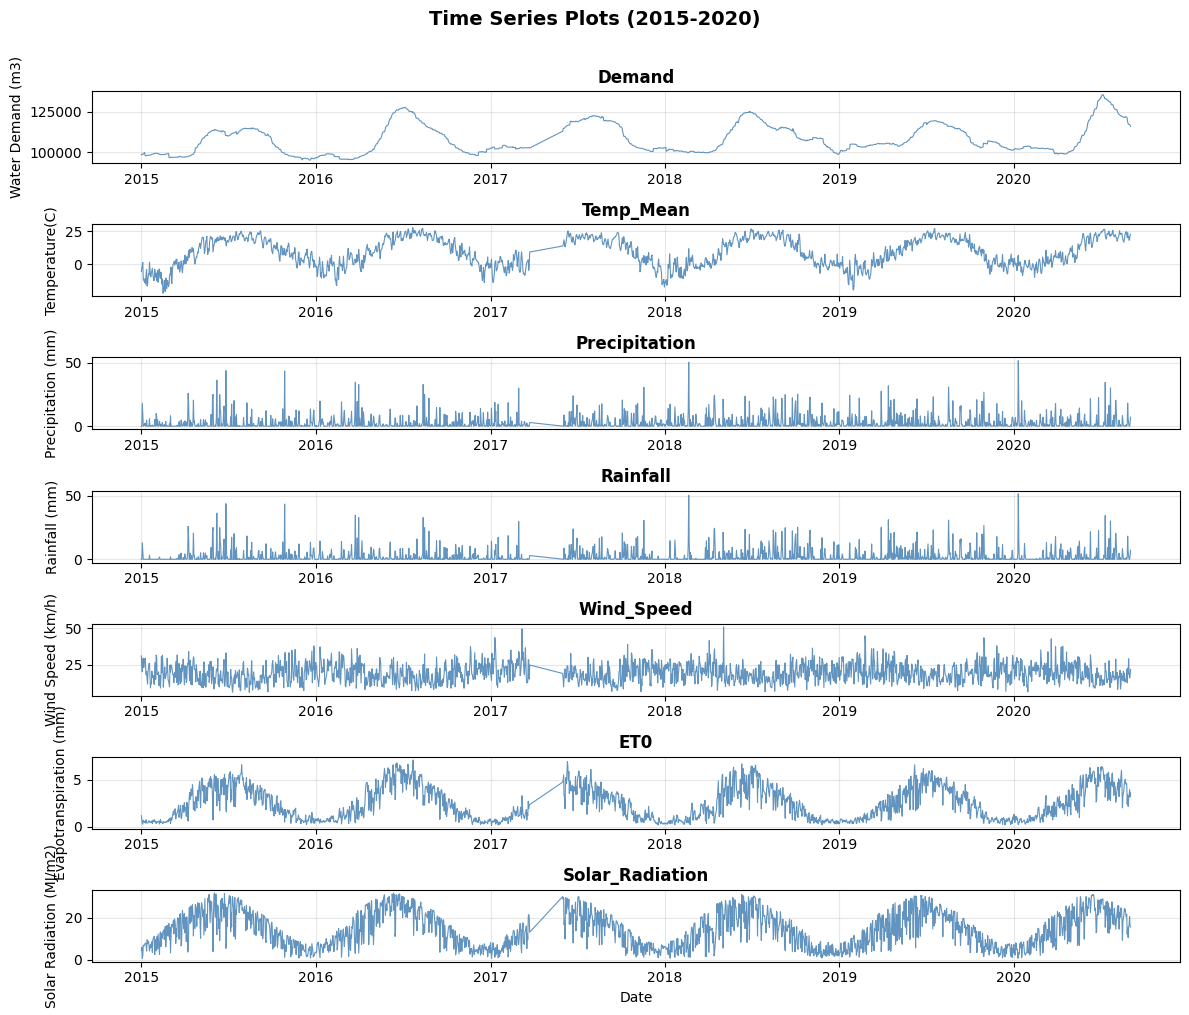

In [ ]:
# all the varaibles
variables = {
    'Demand' : 'Water Demand (m3)',
    'Temp_Mean' : 'Temperature(C)',
    'Precipitation' : 'Precipitation (mm)',
    'Rainfall' : 'Rainfall (mm)',
    'Wind_Speed' :'Wind Speed (km/h)',
    'ET0' : 'Evapotranspiration (mm)',
    'Solar_Radiation':'Solar Radiation (MJ/m2)'
}

fig, axes = plt.subplots(7,1, figsize= (12,10))
# create time series plots for all the variabels
for i,(col,label) in enumerate(variables.items()):
  axes[i].plot(df['Date'], df[col], color='steelblue', linewidth=0.8, alpha=0.85)
  axes[i].set_title(col, fontsize=12, fontweight='bold')
  axes[i].set_ylabel(label, fontsize=10)
  axes[i].set_xlabel('')
  axes[i].grid(True, alpha=0.3)

# show the date label on the bottom plot for visulization purposes
axes[-1].set_xlabel('Date', fontsize=10)
# give a title
plt.suptitle("Time Series Plots (2015-2020)", fontsize=14, fontweight='bold', y= 1.01)
plt.tight_layout()
plt.show()


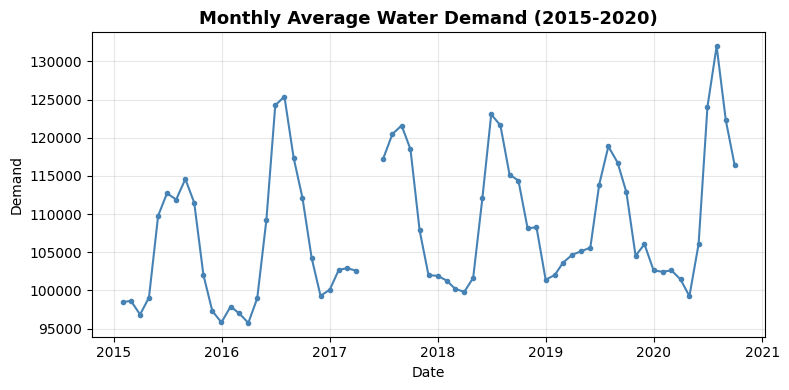

In [ ]:
# monthly data
# group data in time-based(monthly) and take the average demand
# resampling makes the index as Date column
# so reset the index
monthly = df.resample('ME', on='Date')['Demand'].mean().reset_index()

plt.figure(figsize = (8,4))
plt.plot(monthly['Date'], monthly['Demand'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
plt.title('Monthly Average Water Demand (2015-2020)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Based on the plots, water demand(consumption) tends to increase as the average temperature increases. Clear peaks are observed during the summer time (June-August) and the water demand is dropped in winter time(November-January). The same patterns repeats consistently across all years, indicating a strong seasonal influence on water demand. However, rainfall and percipitation don't shows a clear pattern, as the patterns don't follows the similar trend to water demand.

Water demand relatively peaks during the summer months, with the highest observed in 2021 and the second highest in 2016, which is ranging between 125,000 m3 - 135,000m3.  

There is a straight line connecting two data points around mid 2017, which is due to the dataset isn't covering the full year of 2017.

**Correlation Analysis through Heatmap**

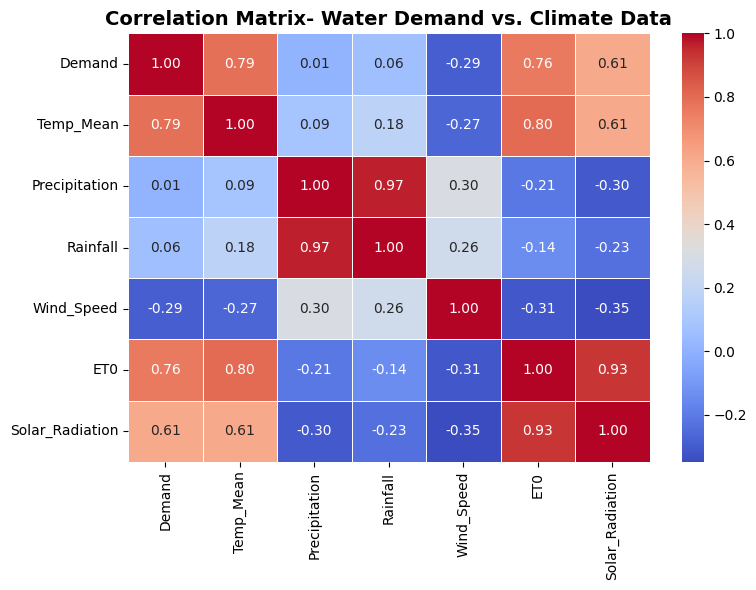

In [ ]:
# correlation matrix
correlation_matrix = df_1.corr()

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f',cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix- Water Demand vs. Climate Data', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The Pearson correlation heatmap reveals the correltion between water demand and climate data. The average temperature shows the strongest positive correlation with water demand, which is 0.79. However, both percipitation and rainfall have low positive correlation, less than 0.1, indicating that the rainfall events have minimal influence on water demand variable. Wind speed shows moderate negative correlation, which is -0.29, meaning that higher wind speeds are associated with lower water demand. Overall based on this heatmap, we can say that the average temperature, ET0 and solar radiation are mainly associated with the water demand.  

## **Model Development**

### **SARIMA Model**



The time series plots reveal a strong seasonarity in the water demand series, during summer and winter months across all years. Because of that, SARIMA was selected over ARIMA model as the SARIMA explicitly models seasonal patterns through its seasonal parameters (P,D,Q,m). So, SARIMA is more appropriate for this dataset. **SARIMA model only looks at the history of water demand itself to make future demand predictions**.

According to the time series analysis, the gap was found to occur between February 2017 and June 2017, approximately more than 60 days. Retaining this gap in the dataset would give a period of missing values, which could negatively impact on the accuracy of the model. Also, imputing more than 60 consecutive data points would mislead the model. So, data imputation is not suitable for this case.

So, prior to the model building, this data gap identified during the time series analysis needs to handle. First, the data is examined to identify the exact time period and the length of data before and after the gap to assess the impact of the gap. Based on the results, a subset of data is used for the modelling.

In [ ]:
df_sorted = df.sort_values('Date').reset_index(drop=True) # sort the dataset based on the Date and drop the current index
date_diff = df_sorted['Date'].diff().dt.days # get the difference between each "Date"
# the difference should be one since working on daily water demand
# if the difference is more than one, then there is a gap
gaps = date_diff[date_diff>1]

# get the first and last day in this gap
# create a for loop to go through gaps
for idx in gaps.index:
  # this gives the last day before the gap started
  gap_start = df_sorted.loc[idx-1, 'Date']
  # the first day after the gap occured
  gap_end = df_sorted.loc[idx, 'Date']
  # print both dates
  print(f'Gap starts on: {gap_start.date()}')
  print(f'Gap ends on: {gap_end.date()}')

# reset the index
df_ts = df.set_index('Date')['Demand']
# create two subsets before and after gap occured
df_aftergap = df_ts[gap_end:]
df_beforegap = df_ts[:gap_start]

print()
print('Number of Data points before the gap occure:', len(df_beforegap))
print('Number of Data points after the gap occured', len(df_aftergap))

Gap starts on: 2017-03-24
Gap ends on: 2017-06-01

Number of Data points before the gap occure: 814
Number of Data points after the gap occured 1190


A single data gap is identified in the water demand data from March 2017 to June 2017. The post-gap period has 1190 datapoints, which is significantly larger than the pre-gap set. Therefore, the post-gap subset is selected for SARIMA model development.

In [ ]:
# subset of data we use for building the model
print('Subset:', df_aftergap.index.min().date(), 'to' , df_aftergap.index.max().date())

Subset: 2017-06-01 to 2020-09-02


**Check Stationarity**

SARIMA model assumes that the underlying time series is stationary, which means the mean and variance of the series doesn't change over time. To verify this assumption, two complementary stationarity test are used.

**ADF Test - Augmented Dickey-Fuller Test**

H0 (null hypothesis) - The series is not stationary

H1 (alternative hypothesis) - The series is stationary

**KPSS Test**

H0 (null hypothesis) - The series is stationary

H1 (alternative hypothesis) - The series is not stationary

If the p-value< 0.05, the H0 is rejected. If not, the H1 is rejected.

In [ ]:
# apply adf test to the dataset, we chose
adf_results = adfuller(df_aftergap, autolag= "AIC")
# print the results
print(f'ADF Statistic: {adf_results[0]:.4f}')
print(f'p-value: {adf_results[1]:.4f}')

ADF Statistic: -4.1294
p-value: 0.0009


In [ ]:
# apply kpss test
kpss_result = kpss(df_aftergap, regression='c', nlags='auto')
# print the results
print(f'KPSS Statistic: {kpss_result[0]:.4f}')
print(f'p-value: {kpss_result[1]:.4f}')

KPSS Statistic: 0.2169
p-value: 0.1000


According to the results,



*   The ADF test returned a p-value of 0.0009(< 0.05), which is less than 0.05. This provides strong evidence to reject the null hypothesis of non-stationarity.
*   The KPSS test returned a p-value of 0.1(>0.05), which is greated than 0.05. This provides strong evidence to confirm the null hypothesis of stationarity.

Both test results are confirmed the stationarity of the unerlying time series in the dataset. Therefore, the SARIMA is used as the model to make future water demand predictions.  



**STL Decomposition**

STL, Seasonal and Trend Decomposition, visually confirms the seasonality in the dataset. The helps to understand how strong the trend, seasonal components. The residual component shows the unexplained variation in the dataset.

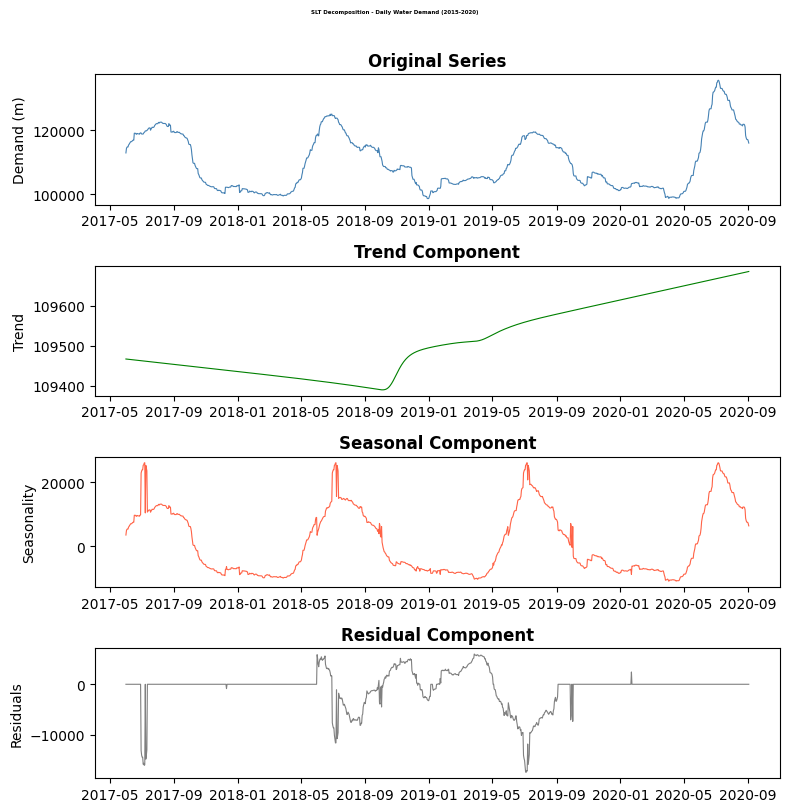

In [ ]:
# fit STL Decomposition
stl = STL(df_aftergap, period=365, robust=True)
slt_result = stl.fit()
# plot all components together
fig, axes = plt.subplots(4,1, figsize=(8,8))
# original water demand
axes[0].plot(df_aftergap, color='steelblue', linewidth = 0.8)
axes[0].set_title('Original Series', fontweight='bold')
axes[0].set_ylabel('Demand (m)')
# trend
axes[1].plot(slt_result.trend, color='green', linewidth = 0.8)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')
# seasonality
axes[2].plot(slt_result.seasonal, color='tomato', linewidth = 0.8)
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonality')
# residuals
axes[3].plot(slt_result.resid, color='gray', linewidth = 0.8)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_ylabel('Residuals')

plt.suptitle("SLT Decomposition - Daily Water Demand (2015-2020)", fontsize=4, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The trend component shows a gradual increase from 109,400 m3 to 109,600 m3, indicating a slow increase in citywide water demand. However, the seasonal component confirms a strong seasonal pattern annually, with summer peak across all the years. The residual component fluctuates around zero.

**SARIMA Parameters**

The next step is to identify the appropriate parameters for the SARIMA model. The AutoCorrelation Function (ACF) and the Partial AutoCorrelation Function (PACF) are used for this. While the ACF measures the correlation between water demand of the current day and all past days across multiple lags, the PACF measures only the direct relationship between the current day and a specific past day. These two plots provide information to identify 'p' and 'q' parameters.

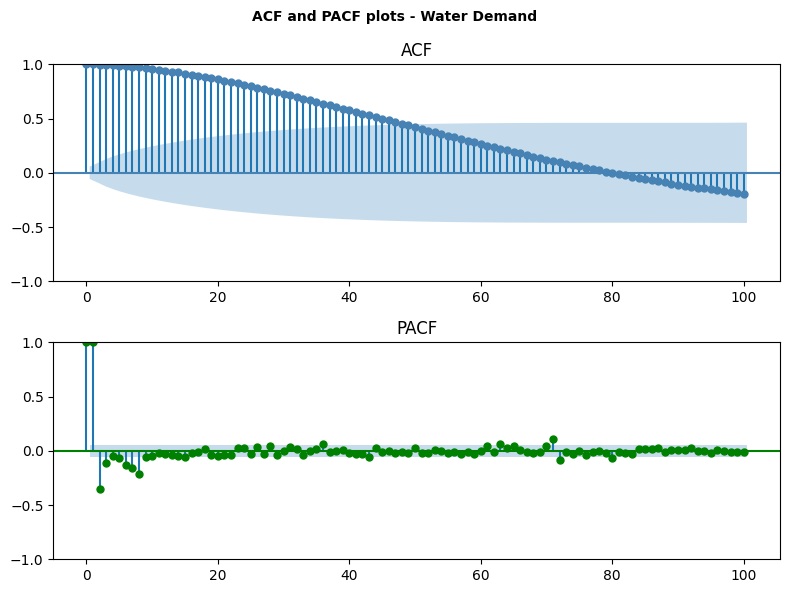

In [ ]:
fig, axes = plt.subplots(2,1, figsize=(8,6))
# plot acf and pacf graphs with 100 time lags
plot_acf(df_aftergap, lags=100, ax=axes[0], color='steelblue', title='ACF')
plot_pacf(df_aftergap, lags=100, ax=axes[1], color='green', title='PACF')

plt.suptitle('ACF and PACF plots - Water Demand', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

According to the results of ACF plot, ACF values are slowly and smoothly decreased and spikes are inside the confidence interval (shade area) after lag 40, indicating that the water demand from 40 days ago has weak influence on today's demand. This figure confirms that the water demand from more than two months ago has less influence on current demand. The q parameter represents the count of lags before sharp cutoff. Since the curve doesn't cut off sharply, we can choose q = 1 as the initial values.

In the PACF plot, after first two lags, the value is dropped down sharply to near zero and stayed inside the confidence interval, meaning that the demand from two days ago has direct influence on today's demand. The p parameter represents the count of lags before cutoff and based on the plot, we can get it as 2.

Therefore, p = 2, q = 1.

d = 0 --> The stationarity tests confirmed that the water demand series is stationary with ADF p-value of 0.0009 and KPSS p-value of 0.1. So, we do not need to perform differecing.

P = Q = 1 --> Standard starting point of seasonal components. These values will be refined if the model indicate poor fit.

D = 1 --> Seasonal differencing to handle annual cycle, ensuring the seasonal component is stable and consistent.

m = 365 --> Annual seasonal cycle.


**Build the SARIMA model**

Prior to model training, the post-gap dataset was partitioned into training and testing sets. The training dataset is for learning underlying patterns and trends, while the testing dataset is for evaluating the model performance in real-world senarios. Due to temporal ordering of time series, a chronological split was applied rather than a random splitting. A random split would introduce data leakage by allowing the model to learn from future data during the training.

In [ ]:
# train_test split
# we split the dataset 80/20 (train/test)
# For that, we get the exact length of the dataset for each subset
train_size = int(len(df_aftergap)*0.8)
# get first set of data (0.8)
train = df_aftergap[:train_size]
# the rest is test data
test = df_aftergap[train_size:]

print('Train data:', train.index.min().date(), 'to', train.index.max().date())
print('Test data:', test.index.min().date(), 'to', test.index.max().date())

Train data: 2017-06-01 to 2020-01-08
Test data: 2020-01-09 to 2020-09-02


Approximately, 80% of the data, from June 2017 to January 2020, was allocated for training, while remaining 20%, from January 2020 to September 2020, was reserved for testing data.


Based on the parameters identified through ACF and PACF analysis, the SARIMA(2,0,1)(1,1,1,365) model was fitted on the training data.  

In [ ]:
# fit the model
model1 = SARIMAX(train, order=(2,0,1), seasonal_order=(1,1,1,300), enforce_stationarity=False, enforce_invertibility=False)
model1_fit = model1.fit(disp=False)
print(model1_fit.summary())

                                      SARIMAX Results                                      
Dep. Variable:                              Demand   No. Observations:                  952
Model:             SARIMAX(2, 0, 1)x(1, 1, 1, 300)   Log Likelihood               -2630.712
Date:                             Thu, 14 May 2026   AIC                           5273.424
Time:                                     22:10:06   BIC                           5296.571
Sample:                                 06-01-2017   HQIC                          5282.637
                                      - 01-08-2020                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.4774      0.096     15.349      0.000       1.289       1.666
ar.L2         -0.4781      

During the training process due to computational limitations, a seasonal period of m=300 was adopted, indicating an approximate 10-months cycle on the daily data. The m=365 caused timeout during the model fitting on Google Colab.

The final selected model SARIMA(2,0,1)(1,1,1,300) reported all p-values below the 0.05 significant level, confirming that parameters are statistically significant. These parameters were retained as the selected model produced comparatively lower AIC, BIC values of approximately 5300 than the models.

According to the autoregressive coefficient at lag 1, which is 1.477, confirms a strong positive influence of yesterdays's demand on today's water demand, while the coefficient of lag 2 reflects a slight negative influence on today's water demand from two days prior (ar.L2 = -0.478).

Regarding model diagnostics, the Ljung-Box test returned a p-value of 0.17, which is above 0.05 significant level, confirming the residuals are white noise with no remianing autocorrelation patterns. Moreover that, the Heteroskedasticity test returned a p-value of 0.07, which is above the significant level of 0.05, inidcating that a constant variance in residuals. However, the kurtosis value of 8.19 suggests that the model contains a heavy tail, indicating that the model is not normally distributed.

However the overall diagnostic results confirms a substantial improvement over the previous configuration and the model was accepted as the final SARIMA model.



**Generate Predictions on Test Data**

The fitted model was used to make predictions on the test dataset. These predicted values were compared against the actual values and visualised in the plot below.

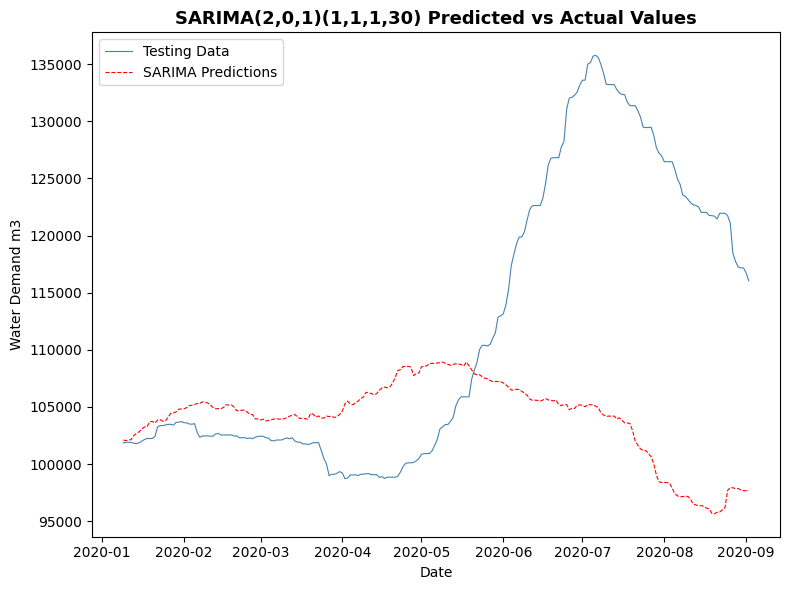

In [ ]:
# make predictions on test dataset
pred = model1_fit.forecast(steps=len(test))

# plot the predicted and actual data
plt.figure(figsize=(8,6))
plt.plot(test.index, test, color="steelblue", linewidth = 0.8, label="Testing Data")
plt.plot(pred.index, pred, color="red", linewidth =0.8, linestyle = "--", label="SARIMA Predictions")
# label x and y axis and give a title
plt.title('SARIMA(2,0,1)(1,1,1,30) Predicted vs Actual Values', fontsize=13, fontweight="bold")
plt.xlabel('Date')
plt.ylabel('Water Demand m3')
plt.legend()
plt.tight_layout()
plt.savefig('SARIMA-Predicted_vs_Actual_Values.png',dpi=150, bbox_inches='tight')
plt.show()

The SARIMA model demonstrates reasonable perfromance during low demand period and captures baseline water demand successfully. However, it significanlty understimates the summer peak demand, with predictions remaining around 95,000 m3 - 110,000 m3 while the actual demand is around 105,000m3 - 135,000 m3. Additionally, from August to September 2020 the predictions decline sharply to around 96,000 m3 while the actual demand remains above 116,000m3, suggesting the model begins to diverge significantly in the latter stages of the forecast.

Limitation for this;
1.   The seasonal period of m=300 represents approximately 10-months cycle and may not fully capture the annual cycle, causing the model to miss the correct timing and magnitude of the summer peak, which follows a 12-months cycle. An attempt was made to fit the model m=365, however the compurtational requirements exceeded available resources.
2.   The SARIMA model is solely relied on historical water demand data and has no knowldge of other conditions such as weather, meaning that the unusually high climate changes observed during the summer could not be incorporated into this predictions.

**Evaluate the SARIMA Model**

The performance of the SARIMA model was evaluated using three standard metrics, mean squared error, mean absolute error, and R2 score. RMSE measures the average magnitude error between predicted and actual values, MAE measures the average absolute error difference  between predicted and actual values, while R2 score represents the proportion of variance of water demand explained by the model.

In [ ]:
# calculate the mean squared error
rmse =np.sqrt(mean_squared_error(test, pred))
# calculate the mean absolute error
mae = mean_absolute_error(test, pred)
# calculate the R2 score
r2 = r2_score(test, pred)

print("SARIMA Model Performance")
print(f'RMSE: {rmse:.2f} m3')
print(f'MAE: {mae:.2f} m3')
print(f'R2: {r2: .4f}')

SARIMA Model Performance
RMSE: 16012.08 m3
MAE: 11756.87 m3
R2: -0.6994


According to the result, the model achieved an RMSE of 16,012 m3, MAE of 11,756 m3 and a negative R2 score of -0.699, indicating that the model performed poorly on the test set. These metrics are consistent with the above prediction vs actual water demand plot.

That means the SARIMA model alone is insufficient for capturing the nonlinear patterns in the dataset.

**Extract Residulas**

To validate the statistical assumptions of the SARIMA model, residuals were extracted from the training period. Residuals represent the difference between the actual water demand values and the fitted values.

A well-fitted SARIMA model is expected that the residuals behave as white noise, meaning they randomly distributed around zero and exhibit no systematic patterns. Also, the model is expected that the residuals have constant variance over time. Violation these assumptions would indicate that the model has failed to identify important underlying patterns in the data.

Residual shape: (952,)
Residual mean: 70.36
Residual std: 5528.28


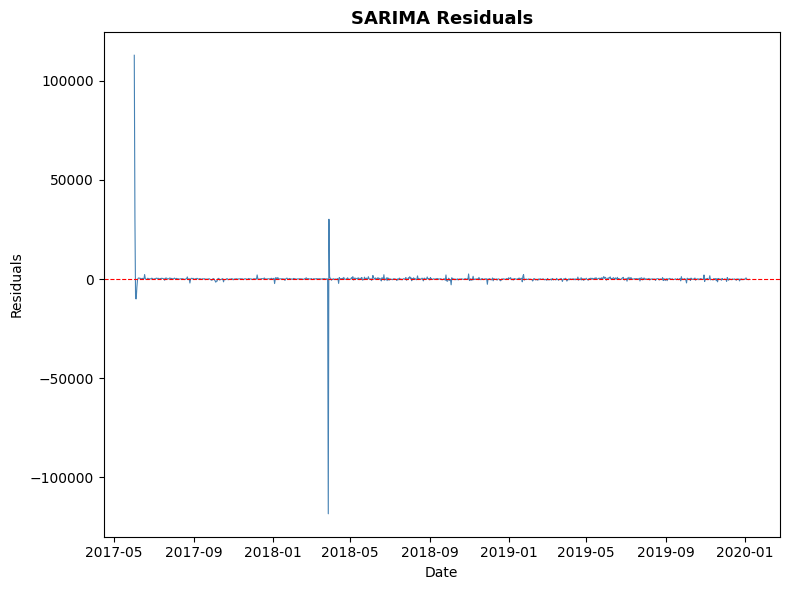

In [ ]:
#extract residuals
residual = model1_fit.resid

print('Residual shape:' , residual.shape)
print('Residual mean:', round(residual.mean(),2))
print('Residual std:', round(residual.std(),2))

#plot the residual
plt.figure(figsize=(8,6))
plt.plot(residual, color='steelblue', linewidth=0.8)
# create a y=0 line
plt.axhline(y=0, color='red', linestyle="--", linewidth=0.8)
plt.title('SARIMA Residuals',fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

Based on the residual plot, two spikes can be identified around June 2017 and April 2018. The second spike occured approximately 300 days after the start date, where the point at which the model requires sufficient historical data to fully learn the 300-day seasonal pattern.

However, following the warmup period, the residuals are clustered around zero with very small magnitude and no systematic patterns, confirming that the SARIMA model has captured linear seasonal components of the water demand successfully. The remaining residuals contain non-linearity and climate-driven demand variations that SARIMA model could not capture. A LSTM model will be developed to learn these components contained within the SARIMA residuals. Prior to passing the residuals to the LSTM model, those spikes need to be removed to prevent the model from learning incorrect patterns during training. These spikes do not reflect and demand behaviour.

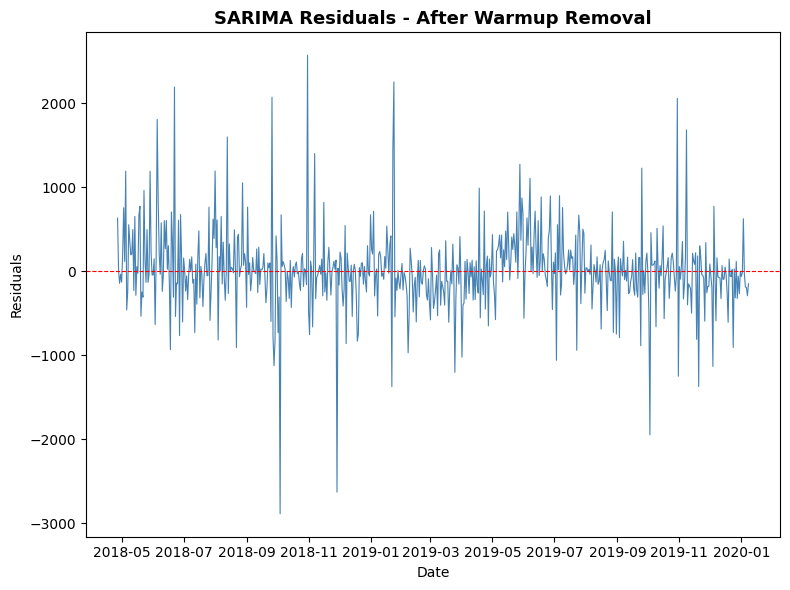

In [ ]:
# drop warmup spikes
sarima_residuals = residual.iloc[330:]
# plot cleaned residuals
plt.figure(figsize=(8,6))
plt.plot(sarima_residuals, color='steelblue', linewidth=0.8)
plt.axhline(y=0, color='red', linestyle="--", linewidth=0.8)
plt.title('SARIMA Residuals - After Warmup Removal',fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.tight_layout()
plt.show()

### **Building LSTM Model**

**Align Residuals with Climate Variables**

The extracted residuals represents unexplained variations in the water demand data that the SARIMA model could not capture. These residuals might contain the underlying influence of climate on water demand. To investigate these underlying patterns, the residuals were merged with the climte data on date column. This merged dataset is used as the input for the LSTM model, which will learn the nonlinearity between climate and water demand and the unexplained demand variation captured in the residuals.

In [ ]:
# get residuals as a data frame
residual_df = sarima_residuals.reset_index()
# rename columns
residual_df.columns = ['Date','Residuals']

#get climate variables
start_date = residual.index.min()
end_date = residual.index.max()
# we use the same data range as residuals
climate_vars = df[(df['Date']>=start_date) & (df['Date'] <= end_date)][['Date','Temp_Mean','Precipitation','Rainfall','Wind_Speed','ET0','Solar_Radiation']]

# create a new data frame with residuals and climate variables
lstm_df = pd.merge(residual_df, climate_vars, on='Date', how='inner')
# sort the data, reset_index(drop=True) removes the previous index
lstm_df = lstm_df.sort_values('Date').reset_index(drop=True)

print("LSTM dataset shape:",lstm_df.shape)
print(lstm_df.head())

LSTM dataset shape: (622, 8)
        Date   Residuals  Temp_Mean  Precipitation  Rainfall  Wind_Speed  \
0 2018-04-27  630.819249   8.433333            1.1       1.1   17.551615   
1 2018-04-28    1.446380   2.887500            0.2       0.2   24.951921   
2 2018-04-29 -143.906973   3.543750            0.0       0.0   24.291330   
3 2018-04-30  -35.685842   8.427083            0.0       0.0   13.779114   
4 2018-05-01 -129.132175  15.445834            0.0       0.0   22.366402   

        ET0  Solar_Radiation  
0  3.310662            22.01  
1  1.345978            11.46  
2  3.341232            27.27  
3  4.435461            27.53  
4  5.443801            25.83  


Following that, the resulting merged dataset contains 622 daily records as input for the LSTM model.

**Normalise Data**

Prior to model development, all numeric values were normalised to ensure consistent scaling across features. As outliers were identified in percipitation, wind speed and rainfall variables during the EDA process, a clipping method was applied at the 99th percentile, perserving 99% of the original data distribution while mitigating the influence of extreme values before scaling. After that, MinMax normalisation was applied to rescale all numeric values to the arange [0,1].

In [ ]:
# apply clipping method for variables with outliers
for col in ['Precipitation','Rainfall','Wind_Speed']:
  # identified the 99th percentile
  upper_bound = lstm_df[col].quantile(0.99)
  # clip those values
  lstm_df[col] = lstm_df[col].clip(upper=upper_bound)
  print(f'{col} clipped at: {upper_bound:.2f}')

x_variables = ['Temp_Mean','Precipitation','Rainfall','Wind_Speed','ET0','Solar_Radiation']
y_variable = 'Residuals'
#use minmax normalisation
# create separate scalers for features and target variables
# becasue all variables have different ranges and if we use one scaler for all the variables
# then the temperature range would influence on how residuals get scaled
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()
x_scaled = feature_scaler.fit_transform(lstm_df[x_variables])
y_scaled = target_scaler.fit_transform(lstm_df[[y_variable]])

Precipitation clipped at: 24.31
Rainfall clipped at: 23.52
Wind_Speed clipped at: 36.36


Identified extreme outliers, which exceed the 99th percentile thersholds of 24.31mm, 23.52mm and 36.36 km/h for percipitation, rainfall and wind speed respectively were capped at their corresponding threshold values. This means that any extreme value beyond these boundaries were replaced by the threshold values.

**Create Sequences**

Prior to the model development, input sequences were created to enable the LSTM model to learn temporal patterns over time. Since the dataset represent a time series, the model requires contextual information from past data rather than individual data point. So, here a sliding window was created with a lookback of 30 days, meaning that for each prediction the model receives the previous 30 days of climate data alongside the corresponding SARIMA residuals as input. This allows the LSTM model to identify and learn the relationship between climate data and water demand.

In [ ]:
# look 30 days back
lookback = 30
# create a sequence with past 30 days
def create_sequence(x,y,lookback):
  # create two arrays for x varibles and residuals
  x_seq, y_seq = [], []
  for i in range(lookback, len(x)):
    x_seq.append(x[i-lookback:i]) # past 30 days of features
    y_seq.append(y[i]) # target value for the current day
  return np.array(x_seq),np.array(y_seq) # create two arrays

x_seq, y_seq = create_sequence(x_scaled, y_scaled, lookback)

**Split Train/Test Data**

Prior to the model building, training, validation and testing sets were created. Approximately 70% of the data was allocated for training, enabling the model to learn underlying temporal and climate-driven patterns within the residuals, while 20% for the testing set for the final unbiased evaluation of the trained model. A validation set was defined to monitor model performance during training and support hyperparameter tuning.  

In [ ]:
#define training, validation and testing dataset size
lstm_train_size = int(len(x_seq)*0.7)
lstm_val_size = int(len(x_seq)*0.1)
# create train, validation and test datasets
x_train = x_seq[:lstm_train_size]
x_val = x_seq[lstm_train_size:lstm_train_size+lstm_val_size]
x_test = x_seq[lstm_train_size+lstm_val_size:]

y_train = y_seq[:lstm_train_size]
y_val = y_seq[lstm_train_size:lstm_train_size+lstm_val_size]
y_test = y_seq[lstm_train_size+lstm_val_size:]
#print the shape of datasets
print('Train data:', x_train.shape)
print('Test data:', x_test.shape)
print('validation data:', x_val.shape)

Train data: (414, 30, 6)
Test data: (119, 30, 6)
validation data: (59, 30, 6)


Folowing the clipping process, all extreme values in precipitation, rainfall and wind speed were capped at their respective 99th percentile thresholds. As a result, the raining, validation and testing sets have 414, 59 and 119 daily records respectively, with each record containing 6 features and 30 days lookback.

**Train the LSTM Model**

The LSTM model was constructed using the sequential data with two LSTM layers and a dense layer on the training dataset. The first layer contained 64 neurons with return_sequences =True, which passes the full output to the next layer. This helps second layer to learn from the complete temporal representation produced by the first layer.

A droput layer with 0.2 was added after the first LSTM layer to randomly deactivate 20% of the neurons during the training process. This helps to reduce the overfitting data.

The second LSTM layer was applied after the first dropout layer with 32 neurons and replace_sequence = False. So, the output sequence is compressed into a single fixed-length vector, which represents learned patterns. Then, second dropout layer was added with the same 0.2 rate for regularisation.

Finally, we have the output layer as dense layer with a single neuron, which produced the predicted residual value for each input sequence.

The model was trained using the Adam optimiser with a 0.001 learning rate. This helps to adapt the learning rate individually for each parameter based on the mean square error loss function, enabling faster convergence and more efficicent weight updates. In total, the model contains 30,625 trainable parameters.

The model was trained with 100 epochs. However, early stopping was implemented as a training callback to prevent overfitting. The callback is monitored the validation loss at the end of each epoch and if no improvement was observed for 10 consecutive epochs (patience = 10), the training process was halted. Upon stopping, the model weights were automatically updates to values from the epoch that produced the lowest validation loss. So, the best performing model was retained instead of the model with the final epoch weights.  

In [ ]:
# set random seed for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

#build the LSTM model
model = Sequential([
    # 64 neurons, passes outputs to the next layer
    LSTM(64,return_sequences=True, input_shape = (lookback,x_seq.shape[2])),
    # deactivate 20% of the neurons during training process
    Dropout(0.2),
    # second LSTM layer with 32 neurons
    LSTM(32,return_sequences=False),
    # second dropout layer with the same 0.2
    Dropout(0.2),
    # output layer with a single neuron
    Dense(1)
])
# complie the model with adam optimizer and 0.001 learning rate,
# meas square error is chosen as the loss function
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 30, 64)         │        18,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# early stopping
early_stop = EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights = True, verbose=1
)

#train the model
train_model = model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_val,y_val), callbacks=[early_stop], verbose=1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.1031 - val_loss: 0.0062
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0242 - val_loss: 0.0068
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0163 - val_loss: 0.0041
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0136 - val_loss: 0.0041
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0131 - val_loss: 0.0043
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0137 - val_loss: 0.0039
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0140 - val_loss: 0.0038
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0139 - val_loss: 0.0038
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0126 - val_loss: 0.0038
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0113 - val_loss: 0.0037
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0133 - val_loss: 0.0037
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step

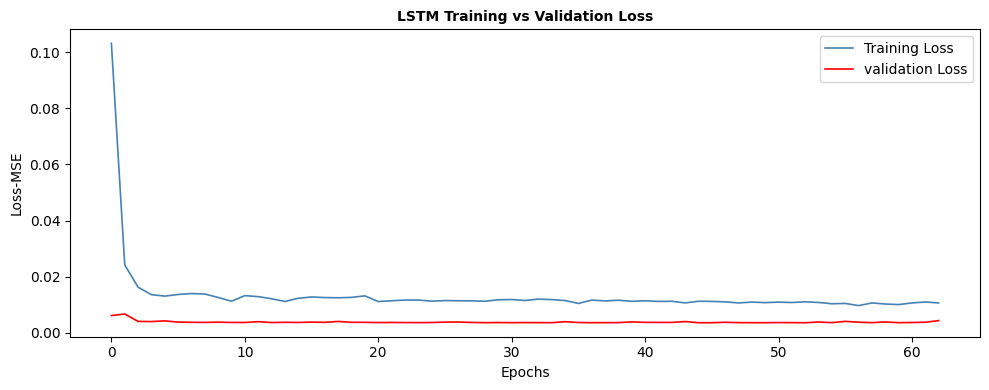

In [ ]:
# plot the loss function
plt.figure(figsize=(10,4))

plt.plot(train_model.history['loss'],color='steelblue', linewidth=1.2, label='Training Loss')
plt.plot(train_model.history['val_loss'], color='red', linewidth=1.2, label='validation Loss')
plt.title('LSTM Training vs Validation Loss', fontsize=10, fontweight='bold')
plt.xlabel('Epochs')
plt.ylabel('Loss-MSE')
plt.legend()
plt.tight_layout()
plt.show()

According to the results, the model converged at epoch 63, where the early stopping was triggered. The model found its optimal weights without requiring the full 100 epochs.

Based on the plot, the training loss began at approximately 0.10 at epoch 0 and decreased sharply to 0.02 by epoch 2 and gradually stabilised at around 0.015. The validation loss began at around 0.005 and stabilised around 0.004 throughout the training process. As dropout introduces noise in training, the training loss function remained above the validation loss. The droput regularisation is diabled during validation. The consistent convergence of both curves without divergence confirmed a successful training without overfitting.  

**Generate Predictions on Test Data**

Predictions were generated on the testing data to evaluate the LSTM model perfromance. These predictions are scaled residuals in the normalised range 0 to 1, because both input features and target variable normalised prior to the training process.

So, the predicted value required inverse transformation to convert back to their original scale. Without converting them back to their original scale, the SARIMA predictions can not be combined with the predicted values.

In [ ]:
# trained model was applied on test data to predict unseen data
y_pred_test = model.predict(x_test)
# inverse transform predictions
y_pred_residuals = target_scaler.inverse_transform(y_pred_test)
y_test_residuals = target_scaler.inverse_transform(y_test)

print("Sample of predicted residuals:", y_pred_residuals[:5].flatten())
print("Sample of actual residuals:", y_test_residuals[:5].flatten())

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
Sample of predicted residuals: [ -93.300354 -135.10925  -173.90115  -170.65704  -146.18057 ]
Sample of actual residuals: [-266.29443624 -247.56852646 -124.90465578  -63.56464223  137.3253146 ]


**Get Corresponding SARIMA Predctions**

To make final hybrid predictions, the SARIMA and LSTM outputs need to align with the same data range. So, the test period dates were extracted from the LSTM dataset using the test set indices, covering September 2019 to January 2020. Then, the SARIMA model was quried to get the predict value for the exact date range.

In [ ]:
# get the dates from LSTM test set
test_start = lstm_train_size + lstm_val_size + lookback
test_dates = lstm_df['Date'].iloc[test_start:].reset_index(drop=True)

print('LSTM test dates:')
print('From:', test_dates.iloc[0].date())
print('To  :', test_dates.iloc[-1].date())
print('Total:', len(test_dates))

# get SARIMA predictions for LSTM test dates
sarima_test_pred = model1_fit.predict(
    start=test_dates.iloc[0], end=test_dates.iloc[-1])
# check if the length is same or not
print()
print('Matched SARIMA predictions:', len(sarima_test_pred))
print('LSTM test samples         :', len(x_test))

LSTM test dates:
From: 2019-09-12
To  : 2020-01-08
Total: 119

Matched SARIMA predictions: 119
LSTM test samples         : 119


**Combine SARIMA + LSTM Predictions**

Once both sets of predictions were aligned over the same dates, the final hybrid predictions was obtained by adding the SARIMA fitted values and LSTM predicted residuals together. Finally, the hybrid predictions were compared with the actual water demand. By adding them together, the model produces a complete forecast that accounts for both the predictable seasonal patterns and the irregular climate-driven demand spikes.

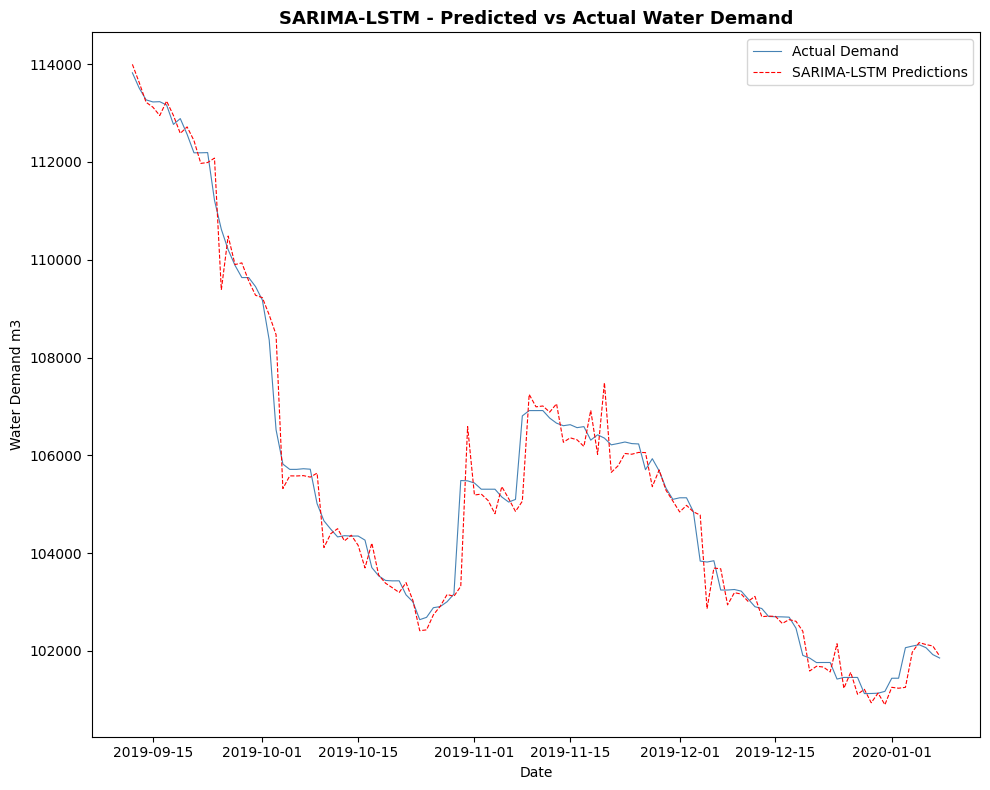

In [ ]:
#combine both SARIMA and LSTM predictiosn
hybrid_pred = sarima_test_pred.values + y_pred_residuals.flatten()
# extract the actula water demand from the original data
actual_demand = df[
    (df['Date'] >= test_dates.iloc[0]) &
    (df['Date'] <= test_dates.iloc[-1])
]['Demand'].values
# plot both together
plt.figure(figsize=(10,8))
plt.plot(test_dates,actual_demand, color='steelblue', linewidth = 0.8, label="Actual Demand")
plt.plot(test_dates, hybrid_pred, color='red', linewidth=0.8, linestyle='--', label = 'SARIMA-LSTM Predictions')
# add labels, titles and legend
plt.title("SARIMA-LSTM - Predicted vs Actual Water Demand", fontsize = 13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Water Demand m3')
plt.legend()
plt.tight_layout()
plt.show()

The actual demand vs predicted plot demonstrated that the hybrid model predictions closel follow the actual water demand throughout the test period from September 2019 to January 2020. Both lines started at approximately 114,000 m3 and decreased together steadily. Demand flctuations and irregular variations were also captured closely by the model, confirming that the hybrid model captured the overall fluctuations during the autumn and winter period. However, the model was not evaluated the summer period since no summer peak was present in the test period.  

**Evaluate Hybrid Model**

The hybrid model predictions were evaluated using three standard performance metrics, RMSE, MAE and R2 score.

In [ ]:
# calculate the mean squared error
rmse =np.sqrt(mean_squared_error(actual_demand, hybrid_pred))
# calculate the mean absolute error
mae = mean_absolute_error(actual_demand, hybrid_pred)
# calculate the R2 score
r2 = r2_score(actual_demand, hybrid_pred)

print("SARIMA-LSTM Hybrid Model Performance")
print(f'RMSE: {rmse:.2f} m3')
print(f'MAE: {mae:.2f} m3')
print(f'R2: {r2: .4f}')

SARIMA-LSTM Hybrid Model Performance
RMSE: 470.45 m3
MAE: 298.73 m3
R2:  0.9804


The SARIMA-LSTM hybrid model achieved 0.98 R2 score on the test dataset, indicating that the model explains 98.04% of variation in the urban water demand in London City, which is a significant improvement over the SARIMA baseline of -54.3%. The predicted vs actual water demand plot also confirmed that the hybrid model closely followed the actual water demand pattern througout the test period.

**Validation on SARIMA Test Data**

The model is evaluated on the SARIMA test dataset to validate the SARIMA-LSTM hybrid model. The corresponding climate variables for this period was extracted and preprocessed using the same clipping and MinMax normalisation during training process. Input sequences were constructed using the final 30 days of the LSTM training data as the initial context window. The trained LSTM model was applied to these sequences to generate residual predictions and SARIMA model was generated forecasts for the same time period. The final hybrid predictions was created by combining both predictions together. And the resulting demand estimate were compared against the actual water demand observations.

SARIMA test dates
From: 2020-01-09
To  : 2020-09-02
Total days: 238



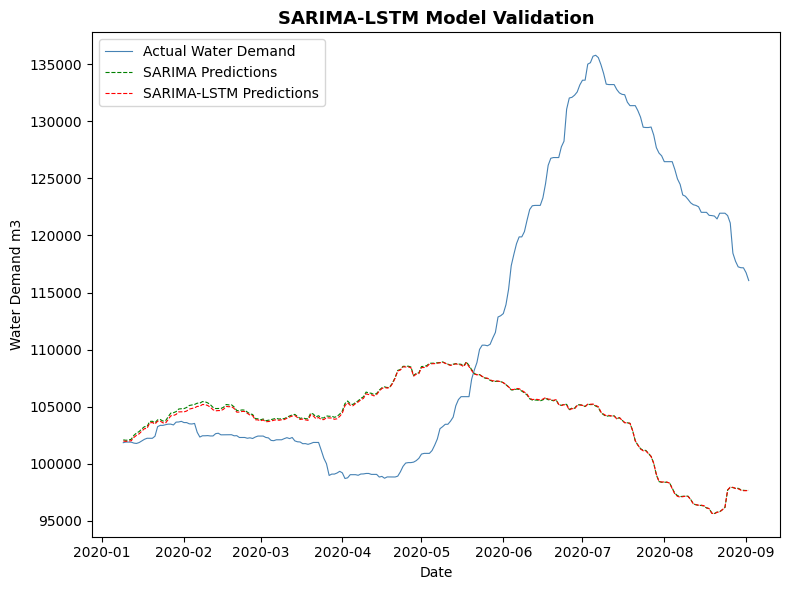

In [ ]:
# get SARIMA test dataset
sarima_testset_start = test.index.min()
sarima_testset_end = test.index.max()
# print the range of test set
print('SARIMA test dates')
print('From:', sarima_testset_start.date())
print('To  :', sarima_testset_end.date())
print('Total days:', len(test))
print()

# get the climate data for this peirod
climate_test = df[
    (df['Date'] >= sarima_testset_start) & (df['Date']<= sarima_testset_end)
][['Temp_Mean','Precipitation','Rainfall','Wind_Speed','ET0','Solar_Radiation']].reset_index(drop=True)


# normalise the data set with clipping
for col in ['Precipitation','Rainfall','Wind_Speed']:
  # use the same clipping values, we used in training data
  upper = lstm_df[col].quantile(0.99)
  # clip values in test data
  climate_test[col] = climate_test[col].clip(upper=upper)

#use minmax normalisation
climate_test_scaled = feature_scaler.transform(climate_test[x_variables])


# create sequences for test period
# get the last 30 days of training data for initial context
last_30_train = x_scaled[-30:]

x_val_test = []
# combining last 30 days of training and test
combined = np.vstack([last_30_train, climate_test_scaled])
# create the sequence
for i in range(lookback,len(combined)):
  x_val_test.append(combined[i-lookback:i])
# make an aray
x_val_test = np.array(x_val_test)


# predict residuals
y_val_pred_scaled = model.predict(x_val_test, verbose=0)
# inverse transform predictions
y_val_pred_residuals = target_scaler.inverse_transform(y_val_pred_scaled).flatten()


# get SARIMA forecast for the same peirod
# this gives predictions on test data
# so we use forecast()
sarima_forecast = model1_fit.forecast(steps=len(test))


# combine both SARIMA and LSTM models
# make sure lengths are same
n = min(len(sarima_forecast), len(y_val_pred_residuals))

hybrid_val_pred = sarima_forecast.values[:n] + y_val_pred_residuals[:n]
# get the actual water demand
actual_val = test.values[:n]
val_dates = test.index[:n]


# plot and compare
plt.figure(figsize=(8,6))
plt.plot(val_dates,actual_val, color='steelblue', linewidth = 0.8, label="Actual Water Demand")
plt.plot(val_dates, sarima_forecast.values[:n], color='green', linewidth=0.8, linestyle='--', label = 'SARIMA Predictions')
plt.plot(val_dates, hybrid_val_pred, color='red', linewidth=0.8, linestyle='--', label = 'SARIMA-LSTM Predictions')

plt.title("SARIMA-LSTM Model Validation", fontsize = 13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Water Demand m3')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# calculate the mean squared error
rmse =np.sqrt(mean_squared_error(actual_val, hybrid_val_pred))
# calculate the mean absolute error
mae = mean_absolute_error(actual_val, hybrid_val_pred)
# calculate the R2 score
r2 = r2_score(actual_val, hybrid_val_pred)

print("SARIMA-LSTM Hybrid Model Performance")
print(f'RMSE: {rmse:.2f} m3')
print(f'MAE: {mae:.2f} m3')
print(f'R2: {r2: .4f}')

SARIMA-LSTM Hybrid Model Performance
RMSE: 15996.10 m3
MAE: 11680.91 m3
R2: -0.6961


During the low demand period from January to May 2020, both SARIMA and hybrid model predictions follow a similar path, indicating that the LSTM component contributes minimal correction during this period, as SARIMA model already captures the baseline demand patterns reasonably well during winter and spring months. However, from June to September 2020, both models failed to capture the sharp summer demand because the LSTM model was also unable to generate sufficiently large residual corrections for the summer period, as the summer period had not been exposed to comparable demand pattern since the SARIMA model trained 10-months cycles instead of annual cycles.

The SARIMA-LSTM hybrid model achieved 15,996 m3 RMSE and 11,680 m3 MAE with -0.6961 R2 score. Still, the overall performance remained poor due to the both models were failed to capture the summer peak in July 2020.

**Feature Importance**

Permutation importance analysis was conducted to identify the relative contribution of each climate variable to the LSTM predictions. Each climate feature was individually shuffeled across the test data and the resulting increase in MSE was recorded as the importance score. Features that produced a larger increase in MSE were considered as more important to the model's perdictive performance.   

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Temp_Mean           :-0.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Precipitation       :0.0000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Rainfall            :0.0002
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Wind_Speed          :0.0005
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
ET0                 :-0.0001
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Solar_Radiation     :0.0000


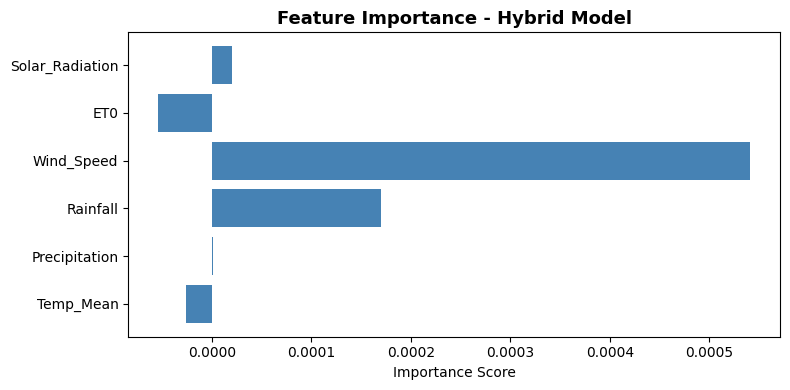

In [ ]:
# make prediction on test data
# calculate the error between actual value and predicted value
# find the MSE by taking the ^2
baseline_loss = np.mean((y_test - model.predict(x_test))**2)
# climate features
features = ['Temp_Mean','Precipitation','Rainfall','Wind_Speed','ET0','Solar_Radiation']
importances = []
# for each feature
for i, feature in enumerate(features):
  np.random.seed(42+i)
  #take the copy of the data
  x_test_copy = x_test.copy()
  # get one feature and shuffle it
  x_test_copy[:,:,i] = np.random.permutation(
      x_test_copy[:,:,i].flatten()
  ).reshape(x_test_copy[:,:,i].shape)
  # measure new losses
  new_loss = np.mean((y_test - model.predict(x_test_copy))**2)
  # take differenc ebetween baseline loss and new loss
  importance = new_loss - baseline_loss
  importances.append(importance)
  print(f'{feature:20s}:{importance:.4f}')
# create the graph
plt.figure(figsize=(8,4))
bars = plt.barh(features, importances, color='steelblue')
plt.xlabel('Importance Score')
plt.title('Feature Importance - Hybrid Model',fontsize=13,fontweight='bold')
plt.tight_layout()
plt.show()


According to the plot, Wind Speed was the most influential climate variable in the LSTM component of the hybrid model and rainfall was the second most important feature. This finding is different from the EDA correlation analysis, which identified average temperature, ET0 and solar radiation as the strongest predcitors of water demand. This is beacuse the LSTM was trained to predict SARIMA residuals rather than direct water demand, which means the LSTM model learned which climate variable explains the patterns that SARIMA could not capture.

So, wind speed and rainfall are the main predictors of unexplained residual variation. Since these two features are absent from the SARIMA model, and wind-driven and rain-driven demand fluctuations are not captured by the statistical component, it appears entirely within the residuals, which the LSTM learned to correct.

Average temperature and ET0 produced negative importance scores, indicating that these features improved model performance slightly. This suggests that within the cotext of residual prediction, temperature and ET0 introduce redunant information that the model does not benefit from.

## **Limitations**



*   The SARIMA model was implemented with a seasonal period m=300 due to computational limitations. It does not fully capture the complete annual cycle of m=365. The full annual seasonal period remains computationally infeasible without access to higher memory resources.

*   The LSTM component was trained on SARIMA residuals from April 2018 to January 2020, covering only autumn and winter conditions. So, the model was never exposed to the summer peak demand. Therefore, this limits the hybrid model's ability to generalise to summer conditions.

*   A gap was identified in the water demand series between March and June 2017, reducing the total training data for both the SARIMA and LSTM components.



## **Conclusion**

This study developed a hybrid model SARIMA-LSTM forecasting model for urban water demand, integrating water consumption data with climate signals from the City of London, Ontario, Canada. The SARIMA model was established a statistical baseline, achieving an R2 score of -0.699 on the test set, confirming that a purely statistical approach was not sufficient for capturing the nonlinearity present in the dataset.

The hybrid-LSTM model demostrated a significant improvement, achieving 0.96 of R2 score within its trained seasonal range. However, this evaluation period falls within the SARIMA model's training range and therefore represents a partially optimistic assessment. When validated on the unseen SARIMA test period, the hybrid model acheived an R2 of -0.747, confirming that both models struggles to generalse to the summer demand peak of 2020 that exceeded the seasonal patterns present in the training data.

Permutation importance analysis identifed wind speed as the most imporatnt feature in the LSTM component, followed by rainfall. Overall, this study demonstrates that hybrid SARIMA-LSTM models can improve urban water demand forecast accuracy within their trained seasonal range. However, the findings highlight a fundermental limitation of data-driven forecasting approaches, whihc is bounded by the range of patterns present in the training data. This ensures that the training data covers complete annual cycles, including summer peak conditions, is essential for developing robust generalised forecasting models for urban water resource management.

## **Future Work**



*   Fitting the SARIMA model with the optimal annual seasonal period of m=365 using high memory computing resources would allow the model fully capture the annual seasonal cycle and improve both baseline and hybrid model performance.

*   Incorporating complete annual cycle in the LSTM training data, including summer peak demand period, would improve the model's ability to generalise to extreme weather conditions.

*   Incorporating more data covering multiple complete annual cycles would ensure the LSTM component is exposed to sufficient summer conditions.

